## The SARIMAX Model

Just like how supervised models use external variables to predict a target variable. 
This idea is very similar to the X part in SARIMAX.

The question, of course, is which one of them you should use in practice. From a 
theoretical point of view, SARIMAX may be preferred in cases where the time series 
part is more present than the external variables part. If the external variables alone 
can explain a lot and this is complemented by a part of autocorrelation or seasonality, 
supervised models may be the better choice.

Let’s see how to improve on the Walmart example using 
external variables.

In [ ]:
# Preparing the data and making a plot
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('../database/walmart-recruiting-store-sales-forecasting-Copy/train.csv/train.csv')
data


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False
421566,45,98,2012-10-05,628.10,False
421567,45,98,2012-10-12,1061.02,False
421568,45,98,2012-10-19,760.01,False


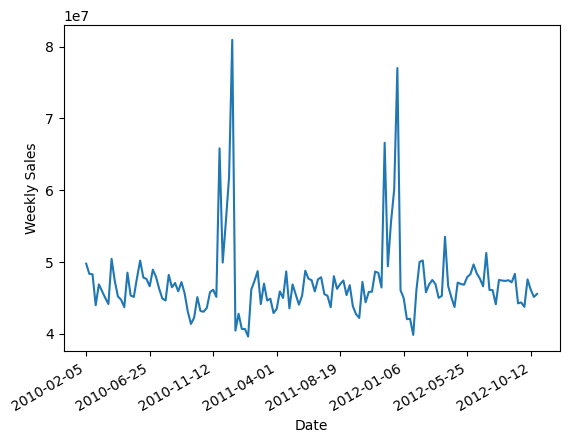

In [2]:
data = data.groupby('Date').sum()
data['IsHoliday'] = data['IsHoliday'] > 0
data['IsHoliday'] = data['IsHoliday'].apply(
lambda x: float(x)
)
ax = data['Weekly_Sales'].plot()
ax.set_ylabel('Weekly Sales')
plt.gcf().autofmt_xdate()
plt.show()

The next step is to use correlation analysis to study whether we may expect an 
improvement from adding the holiday information into the model. If there is no 
correlation at all between sales and holidays, it would be unwise to add it to the model. 

In [4]:
# Is there a correlation between sales and holidays?
data[['Weekly_Sales', 'IsHoliday']].corr()

,Weekly_Sales,IsHoliday
Weekly_Sales,1.000000,0.172683
IsHoliday,0.172683,1.000000


The correlation coefficient between sales and holidays is 0.17. This is not very high, 
but enough to consider adding the variable to the model. The model itself will compute 
the most appropriate coefficient for the variable.

It is important to note the terminology of endog and exog:
* `Endogenous variables (endog)` are the target variable. This is where 
all the time series components will be estimated from. In the current 
case, it is the weekly sales.
* `Exogenous variables (exog)` are explanatory variables. This is where 
the model takes additional correlation from. In the current example, 
this is the holiday variable.

For now, we will not do the hyperparameter search to reduce training time. Remember from the SARIMA model training, the optimal score was found using SARIMA(0,1,1)
(1,1,1),52. So for this example, let’s use SARIMAX(0,1,1)(1,1,1)52. 

c:\Users\pc\Downloads\Python_TimeSeriesAnalysis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\pc\Downloads\Python_TimeSeriesAnalysis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\pc\Downloads\Python_TimeSeriesAnalysis\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


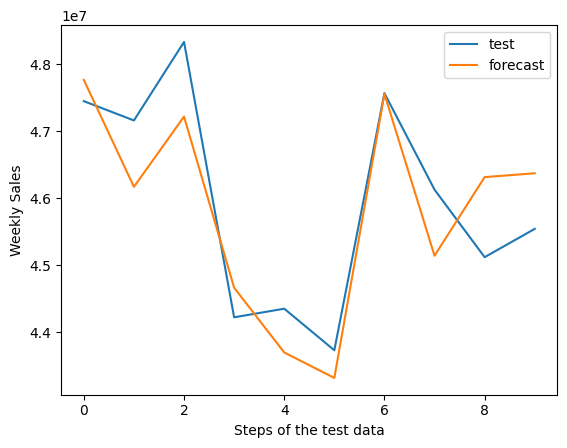

0.7343408623674357

In [5]:
# Fitting a SARIMAX model
import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score

train = data['Weekly_Sales'][:-10]
test = data['Weekly_Sales'][-10:]

mod = SARIMAX(
endog=data['Weekly_Sales'][:-10],
exog=data['IsHoliday'][:-10],
order=(0,1,1),
seasonal_order=(1,1,1,52),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10, exog = data['IsHoliday'][-10:])

plt.plot(list(test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Weekly Sales')
plt.legend(['test', 'forecast'])
plt.show()
r2_score(test, fcst)

From the R2_score, there isn't much effect from the external variables.

We have seen how to use the SARIMAX model using one additional 
variable. Yet remember that there is no limit for the number of exogenous variables included in a SARIMAX model. As long as we can provide future values for this variable, this may work.

`Pay attention here:` many variables that can improve model performances are not useful in practice. For example, you may be able to explain sales by using weather data. 
Yet weather data for the future is not yet known. So while this variable may have an important impact on sales, it cannot be used for improving the forecasting accuracy.

### Key Takeaways
* The SARIMAX model allows for adding external variables to the 
SARIMA model.
* SARIMAX has two types of variables:
    * Endogenous: The target variable
    * Exogenous: The external variables
* You need to specify the future values of the exogenous variable when forecasting. Therefore, when using exogenous variables, it is important to know that you have fixed information for the future about them.
    * A variable like holidays can work, as you know which holidays 
    will occur in the future.
    * A variable like weather cannot work, as you will not know which weather will occur in the future.